In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
ds=pd.read_csv("Book2.csv")

In [3]:
ds.head()

,Unnamed: 0,match_number,team1,team2,match_date,toss_winner,toss_decision,result,winner,player_of_match,...,player_of_match.1,venue.1,winner.2,player_of_match.2,winner.3,player_of_match.3,venue.2,city.1,winner.4,player_of_match.4
0,0,335988,Deccan Chargers,Delhi Daredevils,22-04-2008,Deccan Chargers,bat,Win,Delhi Daredevils,V Sehwag,...,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Delhi Daredevils,V Sehwag,Delhi Daredevils,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Delhi Daredevils,V Sehwag
1,1,419115,Royal Challengers Bangalore,Rajasthan Royals,18-03-2010,Royal Challengers Bangalore,field,Win,Royal Challengers Bangalore,JH Kallis,...,JH Kallis,M Chinnaswamy Stadium,Royal Challengers Bangalore,JH Kallis,Royal Challengers Bangalore,JH Kallis,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,JH Kallis
2,2,1426297,Gujarat Titans,Chennai Super Kings,10-05-2024,Chennai Super Kings,field,Win,Gujarat Titans,Shubman Gill,...,Shubman Gill,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Shubman Gill,Gujarat Titans,Shubman Gill,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,Gujarat Titans,Shubman Gill
3,3,335982,Royal Challengers Bangalore,Kolkata Knight Riders,18-04-2008,Royal Challengers Bangalore,field,Win,Kolkata Knight Riders,BB McCullum,...,BB McCullum,M Chinnaswamy Stadium,Kolkata Knight Riders,BB McCullum,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders,BB McCullum
4,4,981019,Royal Challengers Bangalore,Sunrisers Hyderabad,29-05-2016,Sunrisers Hyderabad,bat,Win,Sunrisers Hyderabad,BCJ Cutting,...,BCJ Cutting,M Chinnaswamy Stadium,Sunrisers Hyderabad,BCJ Cutting,Sunrisers Hyderabad,BCJ Cutting,M Chinnaswamy Stadium,Bangalore,Sunrisers Hyderabad,BCJ Cutting


In [4]:
ds.columns

Index(['Unnamed: 0', 'match_number', 'team1', 'team2', 'match_date',
       'toss_winner', 'toss_decision', 'result', 'winner', 'player_of_match',
       'venue', 'city', 'team1_players', 'winner.1', 'player_of_match.1',
       'venue.1', 'winner.2', 'player_of_match.2', 'winner.3',
       'player_of_match.3', 'venue.2', 'city.1', 'winner.4',
       'player_of_match.4'],
      dtype='object')

In [5]:
ds=ds.drop(columns=['Unnamed: 0','match_number','match_date','result','player_of_match','venue','team1_players','winner.1', 'player_of_match.1',
       'venue.1', 'winner.2', 'player_of_match.2', 'winner.3',
       'player_of_match.3', 'venue.2', 'city.1', 'winner.4',
       'player_of_match.4'])

In [6]:
ds.isnull().sum()

team1             0
team2             0
toss_winner       0
toss_decision     0
winner           23
city             48
dtype: int64

In [7]:
ds=ds.dropna(subset=['winner'])

In [8]:
a=ds['city'].value_counts()

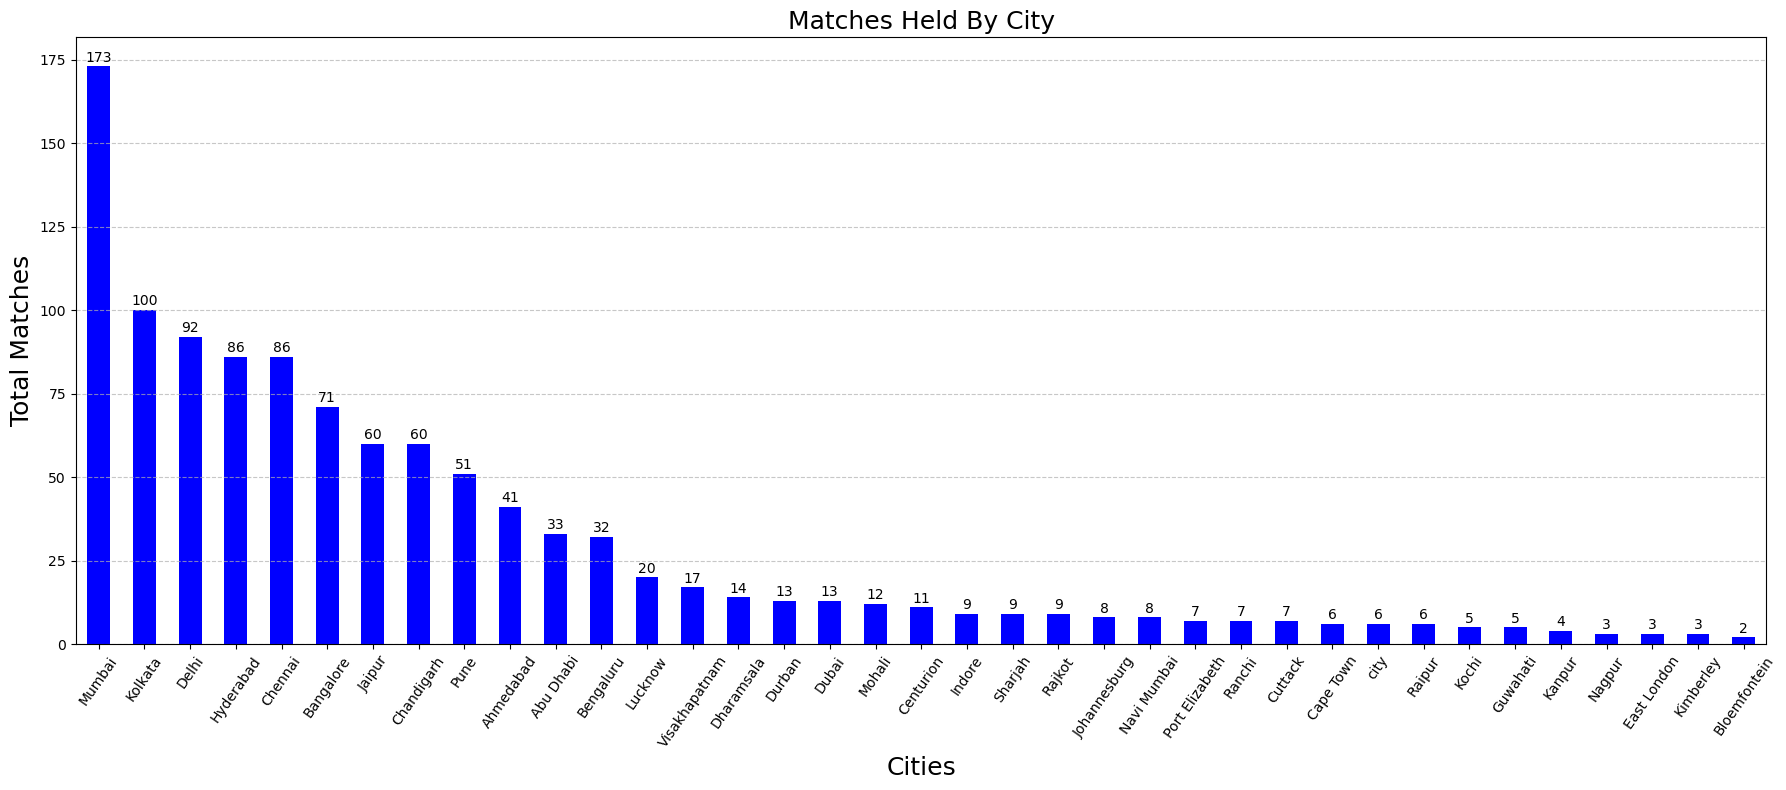

In [9]:
a=ds['city'].value_counts()
p=a.plot(kind="bar",color='blue',figsize=(18,8))
plt.title("Matches Held By City",fontsize=18)
plt.xlabel("Cities",fontsize=18)
plt.ylabel("Total Matches",fontsize=18)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.xticks(rotation=55)
for i,count in enumerate(a):
    p.text(i,count+0.5,str(count),fontsize=10,ha='center',va='bottom')
plt.tight_layout()
plt.show()

In [10]:
ds['city'].isnull().sum()

45

In [11]:
ds['city']=ds['city'].fillna('Mumbai')

In [12]:
ds.head()

,team1,team2,toss_winner,toss_decision,winner,city
0,Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,Delhi Daredevils,Hyderabad
1,Royal Challengers Bangalore,Rajasthan Royals,Royal Challengers Bangalore,field,Royal Challengers Bangalore,Bangalore
2,Gujarat Titans,Chennai Super Kings,Chennai Super Kings,field,Gujarat Titans,Ahmedabad
3,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,Bangalore
4,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,Bangalore


In [13]:
x=['Deccan Chargers','Pune Warriors','Rising Pune Supergiants','Kochi Tuskers Kerala','Rising Pune Supergiant']
for i in x:
    a=ds[ds['team1']==i]
    b=np.array(a.index)
    for j in b:
        ds.drop(j,inplace=True)

In [14]:
team_correction={'Royal Challengers Bangalore':'Royal Challengers Bengaluru','Kings XI Punjab':'Punjab Kings','Gujarat Lions':'Gujarat Titans','Delhi Daredevils':'Delhi Capitals'}
ds['team1']=ds['team1'].replace(team_correction)

In [15]:
ds['team1'].unique()

array(['Royal Challengers Bengaluru', 'Gujarat Titans',
       'Rajasthan Royals', 'Mumbai Indians', 'Sunrisers Hyderabad',
       'Kolkata Knight Riders', 'Chennai Super Kings',
       'Lucknow Super Giants', 'Delhi Capitals', 'Punjab Kings'],
      dtype=object)

In [16]:
x=['Deccan Chargers','Pune Warriors','Rising Pune Supergiants','Kochi Tuskers Kerala','Rising Pune Supergiant']
for i in x:
    a=ds[ds['team2']==i]
    b=np.array(a.index)
    for j in b:
        ds.drop(j,inplace=True)

In [17]:
team_correction={'Royal Challengers Bangalore':'Royal Challengers Bengaluru','Kings XI Punjab':'Punjab Kings','Gujarat Lions':'Gujarat Titans','Delhi Daredevils':'Delhi Capitals'}
ds['team2']=ds['team2'].replace(team_correction)

In [18]:
ds['team2'].unique()

array(['Rajasthan Royals', 'Chennai Super Kings', 'Kolkata Knight Riders',
       'Sunrisers Hyderabad', 'Punjab Kings',
       'Royal Challengers Bengaluru', 'Gujarat Titans', 'Delhi Capitals',
       'Lucknow Super Giants', 'Mumbai Indians'], dtype=object)

In [19]:
team_correction={'Royal Challengers Bangalore':'Royal Challengers Bengaluru','Kings XI Punjab':'Punjab Kings','Gujarat Lions':'Gujarat Titans','Delhi Daredevils':'Delhi Capitals'}
ds['toss_winner']=ds['toss_winner'].replace(team_correction)

In [20]:
ds['toss_winner'].unique()

array(['Royal Challengers Bengaluru', 'Chennai Super Kings',
       'Sunrisers Hyderabad', 'Punjab Kings', 'Rajasthan Royals',
       'Kolkata Knight Riders', 'Delhi Capitals', 'Gujarat Titans',
       'Mumbai Indians', 'Lucknow Super Giants'], dtype=object)

In [21]:
team_correction={'Royal Challengers Bangalore':'Royal Challengers Bengaluru','Kings XI Punjab':'Punjab Kings','Gujarat Lions':'Gujarat Titans','Delhi Daredevils':'Delhi Capitals'}
ds['winner']=ds['winner'].replace(team_correction)

In [22]:
x=['Deccan Chargers','winner']
for i in x:
    a=ds[ds['winner']==i]
    b=a.index
    for j in b:
        ds.drop(j,inplace=True)

In [23]:
ds['winner'].unique()

array(['Royal Challengers Bengaluru', 'Gujarat Titans',
       'Kolkata Knight Riders', 'Sunrisers Hyderabad', 'Rajasthan Royals',
       'Mumbai Indians', 'Punjab Kings', 'Lucknow Super Giants',
       'Chennai Super Kings', 'Delhi Capitals'], dtype=object)

In [24]:
ds['city']=ds['city'].str.replace("Bangalore","Bengaluru")

In [25]:
ds.reset_index(drop=True).to_csv("new_cleaned_ipl.csv")